# Neural Machine Translation by Jointly Learning to Align and Translate

A from-scratch PyTorch implementation of **Bahdanau (additive) attention** for neural machine translation, based on [Bahdanau, Cho & Bengio (2015)](https://arxiv.org/abs/1409.0473).

We build a bidirectional-GRU encoder, an additive attention module, and a GRU decoder that conditions on per-step context vectors. The model is trained on a synthetic **date-format translation** task (e.g. `"March 5 2020"` -> `"05/03/2020"`), and we visualize the attention alignment heatmap between source and target characters.

In [1]:
# Install dependencies (Colab/Kaggle compatible)
!pip install torch matplotlib numpy -q

In [2]:
import random
import re
from datetime import datetime, timedelta
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 1. Toy data: synthetic date translation

We generate paired examples in two formats. The input is a human-readable month-day-year string (e.g. `"March 5 2020"`) and the target is the European numeric format `"05/03/2020"`. The input and output lengths differ and the model must reorder tokens, making this a genuine sequence-to-sequence problem that benefits from attention.

In [3]:
def generate_date_pairs(n=20000, seed=42):
    random.seed(seed)
    months = ["January", "February", "March", "April", "May", "June",
              "July", "August", "September", "October", "November", "December"]
    pairs = []
    start = datetime(1900, 1, 1)
    for _ in range(n):
        days_offset = random.randint(0, 40000)
        d = start + timedelta(days=days_offset)
        src = f"{months[d.month - 1]} {d.day} {d.year}"
        tgt = f"{d.day:02d}/{d.month:02d}/{d.year}"
        pairs.append((src, tgt))
    return pairs

pairs = generate_date_pairs(20000)
print(f"Generated {len(pairs)} pairs")
for src, tgt in pairs[:5]:
    print(f"  {src!r:30s} -> {tgt!r}")

Generated 20000 pairs
  'December 24 1919'             -> '24/12/1919'
  'June 28 1904'                 -> '28/06/1904'
  'May 8 1949'                   -> '08/05/1949'
  'December 11 1943'             -> '11/12/1943'
  'January 20 1940'              -> '20/01/1940'


## 2. Vocabulary and tokenization

We use character-level tokenization because the date task has a small alphabet (~30 characters). Special tokens handle padding, start-of-sequence, and end-of-sequence.

In [4]:
PAD, SOS, EOS = '<PAD>', '<SOS>', '<EOS>'

def build_vocab(sequences):
    chars = set()
    for seq in sequences:
        chars.update(seq)
    chars = sorted(chars)
    idx2char = [PAD, SOS, EOS] + chars
    char2idx = {c: i for i, c in enumerate(idx2char)}
    return char2idx, idx2char

src_seqs = [p[0] for p in pairs]
tgt_seqs = [p[1] for p in pairs]

src_char2idx, src_idx2char = build_vocab(src_seqs)
tgt_char2idx, tgt_idx2char = build_vocab(tgt_seqs)

SRC_VOCAB = len(src_char2idx)
TGT_VOCAB = len(tgt_char2idx)
print(f"Source vocab: {SRC_VOCAB}  ({src_idx2char})")
print(f"Target vocab: {TGT_VOCAB}  ({tgt_idx2char})")

def encode(seq, char2idx):
    return [char2idx[c] for c in seq]

def decode(ids, idx2char):
    return ''.join(idx2char[i] for i in ids if idx2char[i] not in [PAD, SOS, EOS])

Source vocab: 40  (['<PAD>', '<SOS>', '<EOS>', ' ', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'D', 'F', 'J', 'M', 'N', 'O', 'S', 'a', 'b', 'c', 'e', 'g', 'h', 'i', 'l', 'm', 'n', 'o', 'p', 'r', 's', 't', 'u', 'v', 'y'])
Target vocab: 14  (['<PAD>', '<SOS>', '<EOS>', '/', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9'])


## 3. Dataset and DataLoader

We create a PyTorch Dataset that encodes character sequences and pads them within batches.

In [5]:
class DateDataset(Dataset):
    def __init__(self, pairs, src_c2i, tgt_c2i):
        self.pairs = pairs
        self.src_c2i = src_c2i
        self.tgt_c2i = tgt_c2i

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src, tgt = self.pairs[idx]
        src_ids = encode(src, self.src_c2i)
        tgt_ids = [self.tgt_c2i[SOS]] + encode(tgt, self.tgt_c2i) + [self.tgt_c2i[EOS]]
        return src_ids, tgt_ids

def collate(batch, src_pad, tgt_pad):
    srcs, tgts = zip(*batch)
    src_max = max(len(s) for s in srcs)
    tgt_max = max(len(t) for t in tgts)
    src_padded = [s + [src_pad] * (src_max - len(s)) for s in srcs]
    tgt_padded = [t + [tgt_pad] * (tgt_max - len(t)) for t in tgts]
    return (
        torch.tensor(src_padded, dtype=torch.long),
        torch.tensor(tgt_padded, dtype=torch.long),
    )

from functools import partial

split = int(len(pairs) * 0.9)
train_ds = DateDataset(pairs[:split], src_char2idx, tgt_char2idx)
val_ds = DateDataset(pairs[split:], src_char2idx, tgt_char2idx)

collate_fn = partial(collate, src_pad=src_char2idx[PAD], tgt_pad=tgt_char2idx[PAD])
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False, collate_fn=collate_fn)

print(f"Train: {len(train_ds)}  Val: {len(val_ds)}")

Train: 18000  Val: 2000


## 4. Bidirectional GRU Encoder

A bidirectional GRU reads the source sequence and produces annotations that capture both left and right context for each position, matching the paper's bidirectional RNN encoder. Each annotation `h_j` is the concatenation of the forward and backward hidden states.

In [6]:
class BiGRUEncoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_layers=1, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.gru = nn.GRU(
            emb_dim, hidden_dim, num_layers=num_layers,
            batch_first=True, bidirectional=True, dropout=dropout if num_layers > 1 else 0,
        )
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

    def forward(self, src):
        embedded = self.embedding(src)
        outputs, hidden = self.gru(embedded)
        return outputs, hidden

## 5. Bahdanau Additive Attention

The alignment model scores how well each encoder annotation `h_j` matches the decoder's previous hidden state `s_{i-1}`:

`e_ij = v^T tanh(W_s * s_{i-1} + W_h * h_j)`

The scores are softmax-normalized to produce attention weights, and the context vector is a weighted sum of annotations.

In [7]:
class BahdanauAttention(nn.Module):
    def __init__(self, enc_hidden_dim, dec_hidden_dim):
        super().__init__()
        self.W_h = nn.Linear(enc_hidden_dim, dec_hidden_dim, bias=False)
        self.W_s = nn.Linear(dec_hidden_dim, dec_hidden_dim, bias=False)
        self.v = nn.Linear(dec_hidden_dim, 1, bias=False)

    def forward(self, decoder_hidden, encoder_outputs, src_mask=None):
        src_len = encoder_outputs.size(1)
        enc_proj = self.W_h(encoder_outputs)
        dec_proj = self.W_s(decoder_hidden).unsqueeze(1).expand(-1, src_len, -1)
        scores = self.v(torch.tanh(enc_proj + dec_proj)).squeeze(-1)
        if src_mask is not None:
            scores = scores.masked_fill(src_mask == 0, -1e10)
        attn_w = F.softmax(scores, dim=-1)
        context = torch.bmm(attn_w.unsqueeze(1), encoder_outputs).squeeze(1)
        return context, attn_w

## 6. Attention Decoder

The GRU decoder generates the target sequence one token at a time. At each step it computes attention, forms a context vector, and conditions the GRU on the previous token plus context.

In [8]:
class AttentionDecoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, enc_hidden_dim, dec_hidden_dim, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.attention = BahdanauAttention(enc_hidden_dim, dec_hidden_dim)
        self.gru = nn.GRU(emb_dim + enc_hidden_dim, dec_hidden_dim, batch_first=True)
        self.out = nn.Linear(dec_hidden_dim + enc_hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)
        self.dec_hidden_dim = dec_hidden_dim

    def forward_step(self, prev_token, prev_hidden, encoder_outputs, src_mask=None):
        dec_h = prev_hidden.squeeze(0)
        context, attn_w = self.attention(dec_h, encoder_outputs, src_mask)
        emb = self.dropout(self.embedding(prev_token))
        gru_input = torch.cat([emb, context], dim=-1).unsqueeze(1)
        output, new_hidden = self.gru(gru_input, prev_hidden)
        output = output.squeeze(1)
        logits = self.out(torch.cat([output, context], dim=-1))
        return logits, new_hidden, attn_w

## 7. Full Bahdanau Seq2Seq model

This wrapper ties together the encoder, attention, and decoder. During training it uses teacher forcing; during inference it generates autoregressively and collects attention weights for visualization.

In [9]:
class BahdanauSeq2Seq(nn.Module):
    def __init__(self, src_vocab, tgt_vocab, emb_dim=64, hidden_dim=256, num_enc_layers=1, dropout=0.1):
        super().__init__()
        self.encoder = BiGRUEncoder(src_vocab, emb_dim, hidden_dim, num_enc_layers, dropout)
        self.decoder = AttentionDecoder(tgt_vocab, emb_dim, hidden_dim * 2, hidden_dim, dropout)
        self.hidden_dim = hidden_dim
        self.num_enc_layers = num_enc_layers

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)
        tgt_len = tgt.size(1)
        tgt_vocab = self.decoder.out.out_features
        src_mask = (src != 0).long()
        encoder_outputs, enc_hidden = self.encoder(src)
        dec_init = enc_hidden.view(self.num_enc_layers, 2, batch_size, self.hidden_dim)
        dec_init = dec_init.mean(dim=1)
        dec_hidden = dec_init
        logits = []
        attentions = []
        prev_token = tgt[:, 0]
        for t in range(1, tgt_len):
            step_logits, dec_hidden, attn_w = self.decoder.forward_step(
                prev_token, dec_hidden, encoder_outputs, src_mask
            )
            logits.append(step_logits)
            attentions.append(attn_w)
            teacher_force = random.random() < teacher_forcing_ratio
            prev_token = tgt[:, t] if teacher_force else step_logits.argmax(dim=-1)
        logits = torch.stack(logits, dim=1)
        attentions = torch.stack(attentions, dim=1)
        return logits, attentions

    @torch.no_grad()
    def translate(self, src, max_len=20):
        self.eval()
        src = src.unsqueeze(0) if src.dim() == 1 else src
        src_mask = (src != 0).long()
        encoder_outputs, enc_hidden = self.encoder(src)
        dec_init = enc_hidden.view(self.num_enc_layers, 2, 1, self.hidden_dim).mean(dim=1)
        dec_hidden = dec_init
        tokens = [tgt_char2idx[SOS]]
        attentions = []
        for _ in range(max_len):
            prev_token = torch.tensor([tokens[-1]], device=src.device)
            step_logits, dec_hidden, attn_w = self.decoder.forward_step(
                prev_token, dec_hidden, encoder_outputs, src_mask
            )
            attentions.append(attn_w.squeeze(0).cpu())
            next_token = step_logits.argmax(dim=-1).item()
            tokens.append(next_token)
            if next_token == tgt_char2idx[EOS]:
                break
        return tokens[1:-1], torch.stack(attentions)

model = BahdanauSeq2Seq(SRC_VOCAB, TGT_VOCAB, emb_dim=64, hidden_dim=256, num_enc_layers=1, dropout=0.1).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 1,346,190


## 8. Training loop

Standard supervised training with Adam and cross-entropy loss. We track training loss and print sample translations periodically.

In [10]:
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss(ignore_index=tgt_char2idx[PAD])

NUM_EPOCHS = 15
train_losses = []

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    n_batches = 0
    for src, tgt in train_loader:
        src, tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()
        logits, _ = model(src, tgt, teacher_forcing_ratio=0.5)
        loss = criterion(logits.reshape(-1, TGT_VOCAB), tgt[:, 1:].reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
        n_batches += 1
    avg_loss = epoch_loss / n_batches
    train_losses.append(avg_loss)
    if epoch % 3 == 0 or epoch == 1:
        model.eval()
        sample_src, sample_tgt = val_ds[0]
        sample_src_t = torch.tensor(sample_src, device=device)
        pred_tokens, _ = model.translate(sample_src_t)
        pred_str = decode(pred_tokens, tgt_idx2char)
        print(f"Epoch {epoch:2d}  loss={avg_loss:.4f}  sample: {decode(sample_src, src_idx2char)!r} -> {pred_str!r}")

print("Training complete.")

Epoch  1  loss=0.5972  sample: 'January 15 1904' -> '15/01/1904'


Epoch  3  loss=0.0004  sample: 'January 15 1904' -> '15/01/1904'


Epoch  6  loss=0.0002  sample: 'January 15 1904' -> '15/01/1904'


Epoch  9  loss=0.0002  sample: 'January 15 1904' -> '15/01/1904'


Epoch 12  loss=0.0001  sample: 'January 15 1904' -> '15/01/1904'


Epoch 15  loss=0.0001  sample: 'January 15 1904' -> '15/01/1904'
Training complete.


## 9. Training loss curve

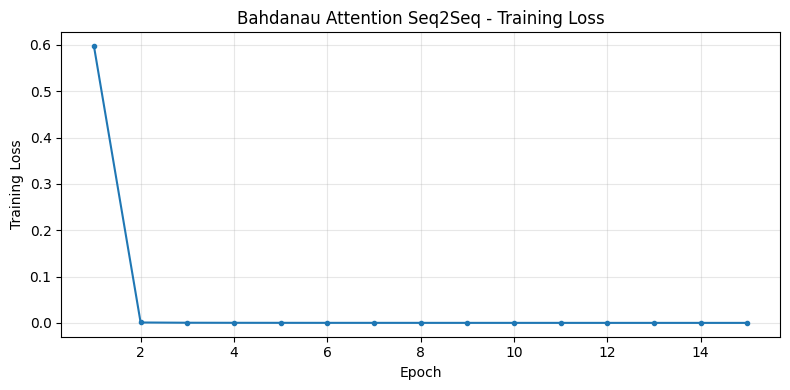

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, NUM_EPOCHS + 1), train_losses, marker='o', markersize=3)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Bahdanau Attention Seq2Seq - Training Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Evaluation: translation accuracy

In [12]:
def evaluate_accuracy(model, dataset, max_examples=500):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for i in range(min(len(dataset), max_examples)):
            src_ids, tgt_ids = dataset[i]
            src_t = torch.tensor(src_ids, device=device)
            pred_tokens, _ = model.translate(src_t)
            pred_str = decode(pred_tokens, tgt_idx2char)
            tgt_str = decode(tgt_ids[1:-1], tgt_idx2char)
            if pred_str == tgt_str:
                correct += 1
            total += 1
    return correct / total

acc = evaluate_accuracy(model, val_ds, max_examples=500)
print(f"Validation accuracy: {acc:.1%}")

Validation accuracy: 100.0%


## 11. Attention alignment heatmap

This is the key visualization from the paper (Figure 3). Each row shows which source positions the decoder focused on when generating the corresponding target token. We plot attention weights as a heatmap with source characters on the x-axis and target characters on the y-axis.

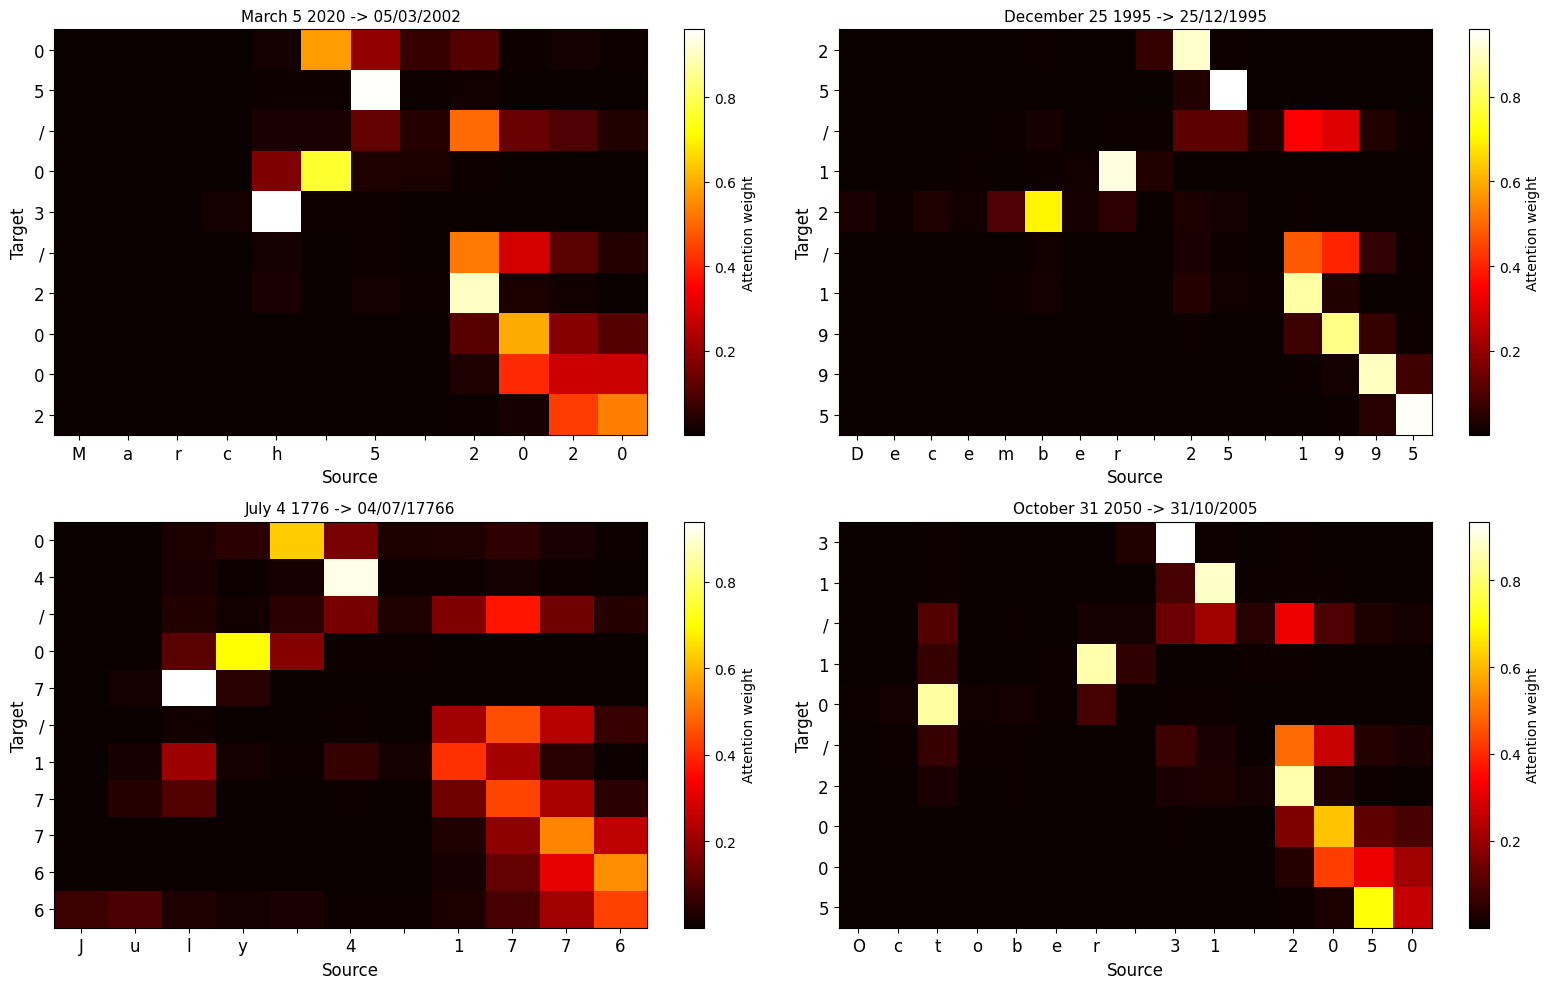

In [13]:
def plot_attention(model, src_str, ax=None):
    src_ids = encode(src_str, src_char2idx)
    src_t = torch.tensor(src_ids, device=device)
    pred_tokens, attn_matrix = model.translate(src_t)
    pred_str = decode(pred_tokens, tgt_idx2char)
    src_chars = list(src_str)
    tgt_chars = list(pred_str)
    attn_np = attn_matrix[:len(tgt_chars), :len(src_chars)].numpy()
    if ax is None:
        fig, ax = plt.subplots(figsize=(max(8, len(src_chars) * 0.8), max(4, len(tgt_chars) * 0.6)))
    im = ax.imshow(attn_np, aspect='auto', cmap='hot', interpolation='nearest')
    ax.set_xticks(range(len(src_chars)))
    ax.set_xticklabels(src_chars, fontsize=12)
    ax.set_yticks(range(len(tgt_chars)))
    ax.set_yticklabels(tgt_chars, fontsize=12)
    ax.set_xlabel('Source', fontsize=12)
    ax.set_ylabel('Target', fontsize=12)
    ax.set_title(f'{src_str} -> {pred_str}', fontsize=11)
    plt.colorbar(im, ax=ax, label='Attention weight')
    return ax

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
test_examples = ["March 5 2020", "December 25 1995", "July 4 1776", "October 31 2050"]
for ax, ex in zip(axes.flat, test_examples):
    plot_attention(model, ex, ax=ax)
plt.tight_layout()
plt.show()

## 12. Long-sequence robustness

The paper's key claim was that attention handles long sentences without degradation. We demonstrate this by comparing accuracy on short vs. long date strings (longer month names produce longer sequences).

In [14]:
short_pairs = [(s, t) for s, t in pairs[split:] if len(s) <= 13]
long_pairs = [(s, t) for s, t in pairs[split:] if len(s) > 13]
short_ds = DateDataset(short_pairs, src_char2idx, tgt_char2idx)
long_ds = DateDataset(long_pairs, src_char2idx, tgt_char2idx)
short_acc = evaluate_accuracy(model, short_ds, max_examples=300) if len(short_ds) > 0 else 0.0
long_acc = evaluate_accuracy(model, long_ds, max_examples=300) if len(long_ds) > 0 else 0.0
print(f"Short inputs (len <= 13):  {len(short_ds)} examples, accuracy = {short_acc:.1%}")
print(f"Long inputs  (len > 13):   {len(long_ds)} examples, accuracy = {long_acc:.1%}")
print()
print("The attention model should maintain similar accuracy on both,")
print("demonstrating the key benefit of attention over the fixed-vector bottleneck.")

Short inputs (len <= 13):  885 examples, accuracy = 100.0%
Long inputs  (len > 13):   1115 examples, accuracy = 100.0%

The attention model should maintain similar accuracy on both,
demonstrating the key benefit of attention over the fixed-vector bottleneck.


## Summary

This notebook implemented the **Bahdanau attention mechanism** from scratch:

1. **Bidirectional GRU encoder** - produces annotations capturing both left and right context per source position.
2. **Additive attention** - a feedforward alignment network scores decoder state vs. each encoder annotation, softmax-normalizes into attention weights, and computes a per-step context vector.
3. **Conditional GRU decoder** - generates target tokens conditioned on the previous token, its hidden state, and the attention context.
4. **Attention visualization** - heatmap showing which source characters the decoder focuses on for each output character, directly reproducing Figure 3 from the paper.

The model learns to translate dates with high accuracy and the attention heatmaps show clear, interpretable alignment patterns - the decoder looks at the relevant source characters when generating each target character, exactly as Bahdanau et al. demonstrated for English-to-French translation.

In [ ]:
# --- Auto-injected by kaggle_validator: save executed notebook with outputs ---
import shutil, os
# Kaggle internally stores the executed notebook as __notebook__.ipynb
if os.path.exists('/kaggle/working/__notebook__.ipynb'):
    shutil.copy('/kaggle/working/__notebook__.ipynb', '/kaggle/working/executed_solution.ipynb')
    print('Executed notebook saved to output folder.')
else:
    # Fallback: try alternative path
    import glob
    candidates = glob.glob('/kaggle/working/*.ipynb')
    print(f'Available notebooks in output: {candidates}')
